In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**1.Which customer segments (Age Group × Geography × Gender) have the highest churn rate?**

In [2]:
df=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query1.csv")
df

,age_group,Geography,Gender,Total_Customers,Churned_Customers,churn_rate
0,50-64,Germany,Female,171,121,70.76
1,50-64,Germany,Male,159,103,64.78
2,50-64,France,Female,235,139,59.15
3,50-64,Spain,Female,128,62,48.44
4,65-79,Germany,Female,28,12,42.86
5,50-64,France,Male,280,112,40.00
6,50-64,Spain,Male,140,54,38.57
7,30-49,Germany,Female,823,286,34.75
8,30-49,Germany,Male,914,236,25.82
9,65-79,Germany,Male,39,9,23.08


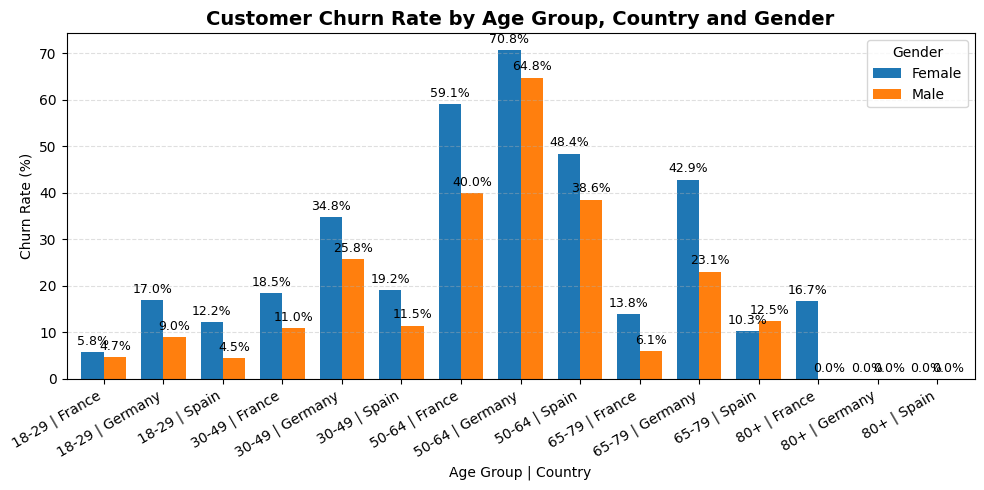

In [7]:


# Combine Age Group and Country for x-axis
df["Group"] = df["age_group"] + " | " + df["Geography"]

# Pivot data
pivot_df = df.pivot(index="Group", columns="Gender", values="churn_rate")

# Plot grouped bar chart
ax = pivot_df.plot(
    kind="bar",
    figsize=(10,5),
    width=0.75
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

# Formatting
plt.title("Customer Churn Rate by Age Group, Country and Gender", fontsize=14, fontweight="bold")
plt.xlabel("Age Group | Country")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**1.1 Which Customer Segment has highest churn**

In [3]:
df1a=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query1.1.csv")
df1a

,Geography,Gender,total_customers,total_churned,churn_rate
0,Germany,Female,1193,448,37.55
1,Germany,Male,1316,366,27.81
2,Spain,Female,1089,231,21.21
3,France,Female,2261,460,20.34
4,Spain,Male,1388,182,13.11
5,France,Male,2753,350,12.71


Gender     Female   Male
Geography               
France      20.34  12.71
Germany     37.55  27.81
Spain       21.21  13.11


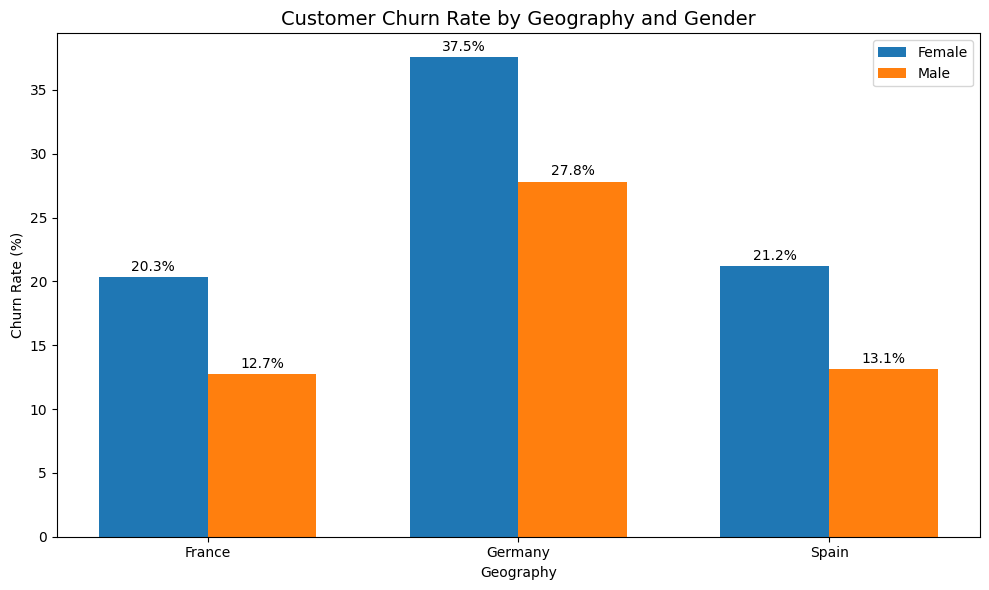

In [6]:


# Create pivot table
pivot_df = df1a.pivot(
    index="Geography",
    columns="Gender",
    values="churn_rate"
)

print(pivot_df)

# Create chart
x = np.arange(len(pivot_df.index))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    pivot_df["Female"],
    width,
    label="Female"
)

plt.bar(
    x + width/2,
    pivot_df["Male"],
    width,
    label="Male"
)

plt.title("Customer Churn Rate by Geography and Gender", fontsize=14)
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.xticks(x, pivot_df.index)
plt.legend()

# Add labels
for i, val in enumerate(pivot_df["Female"]):
    plt.text(i - width/2, val + 0.5, f"{val:.1f}%", ha="center")

for i, val in enumerate(pivot_df["Male"]):
    plt.text(i + width/2, val + 0.5, f"{val:.1f}%", ha="center")

plt.tight_layout()
plt.show()

**2.Rank countries by churn rate and compare them with average customer balance and salary.**

In [8]:
df1=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query2.csv")
df1

,Geography,total_customers,avg_balance,avg_salary,churn_rate,churn_rank
0,Germany,2509,119730.12,101113.44,32.44,1
1,Spain,2477,61818.15,99440.57,16.67,2
2,France,5014,62092.64,99899.18,16.15,3


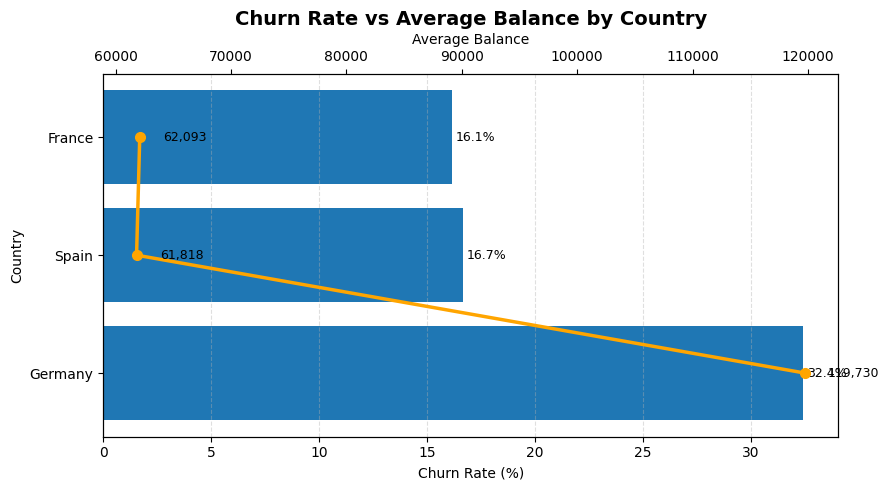

In [10]:


# Sort by churn rate (highest first)
df1 = df1.sort_values("churn_rate", ascending=False)

# Create figure
fig, ax1 = plt.subplots(figsize=(9,5))

# Horizontal bar chart (Churn Rate)
bars = ax1.barh(df1["Geography"], df1["churn_rate"])

# Data labels for bars
ax1.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)

ax1.set_xlabel("Churn Rate (%)")
ax1.set_ylabel("Country")
ax1.set_title("Churn Rate vs Average Balance by Country",
              fontsize=14, fontweight="bold")
ax1.grid(axis="x", linestyle="--", alpha=0.4)

# Secondary axis (Average Balance)
ax2 = ax1.twiny()
ax2.plot(
    df1["avg_balance"],
    df1["Geography"],
    color="orange",
    marker="o",
    linewidth=2.5,
    markersize=7
)
ax2.set_xlabel("Average Balance")

# Data labels for line
for x, y in zip(df1["avg_balance"], df1["Geography"]):
    ax2.text(x + 2000, y, f"{x:,.0f}",
             va="center", fontsize=9)

plt.tight_layout()
plt.show()

**3.Identify the top 10 high-value customers who churned (highest balance + salary + credit score).**

In [11]:
df2=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query3.csv")
df2

,CustomerId,Surname,Balance,CreditScore,EstimatedSalary
0,15757408,Lo,250898.09,655,81054.00
1,15715622,To Rot,238387.56,583,147964.99
2,15714241,Haddon,222267.63,749,101108.85
3,15571958,McIntosh,221532.80,489,171867.08
4,15586674,Shaw,216109.88,663,74176.71
5,15599131,Dilke,214346.96,650,128815.33
6,15594408,Chia,213146.20,584,75161.25
7,15769818,Moore,212778.20,850,69372.88
8,15620268,Thomson,212696.32,634,115268.86
9,15780212,Mao,212692.97,592,176395.02


**3.1.Identify the top 10 high-value customers who churned (highest balance + salary)**

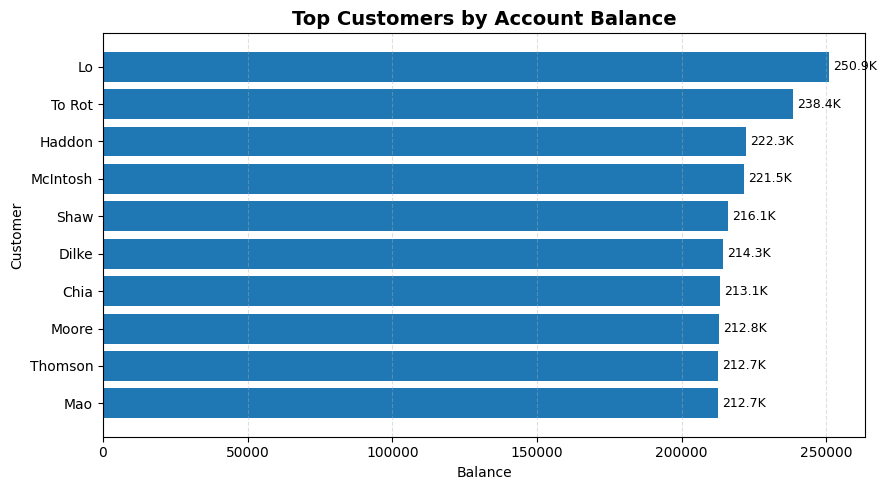

In [12]:


# Sort by Balance
df2 = df2.sort_values("Balance", ascending=True)

# Create figure
plt.figure(figsize=(9,5))

# Horizontal bar chart
bars = plt.barh(df2["Surname"], df2["Balance"])

# Data labels
plt.bar_label(
    bars,
    labels=[f"{x/1000:.1f}K" for x in df2["Balance"]],
    padding=3,
    fontsize=9
)

# Formatting
plt.title("Top Customers by Account Balance", fontsize=14, fontweight="bold")
plt.xlabel("Balance")
plt.ylabel("Customer")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**4.Does being an active member reduce churn? Compare churn rate, average balance, and average salary between active and inactive customers.**

In [13]:
df3=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query4.csv")
df3

,member_status,total_customers,Avg_Salary,Avg_Credit_Score,Avg_Balance,Avg_products_taken,churn_rate
0,Active Member,5151,99452.97,652.93,75875.42,1.54,14.27
1,Inactive Member,4849,100767.20,647.97,77134.38,1.52,26.85


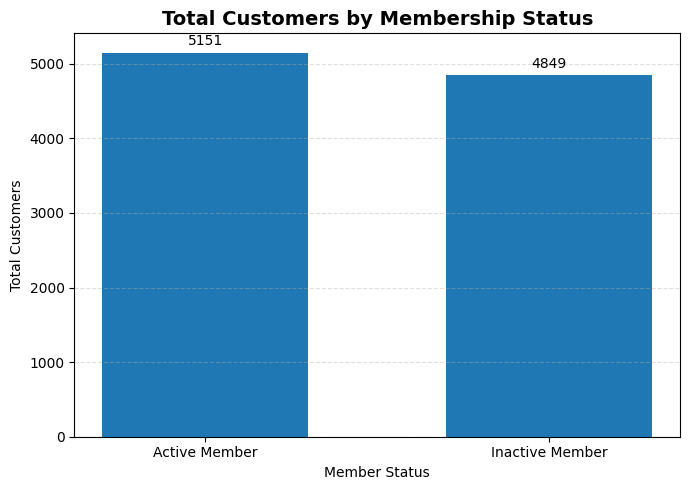

In [15]:


# Create figure
plt.figure(figsize=(7,5))

# Clustered bar chart
bars = plt.bar(df3["member_status"], df3["total_customers"], width=0.6)

# Data labels
plt.bar_label(bars, fmt="%d", padding=3, fontsize=10)

# Formatting
plt.title("Total Customers by Membership Status", fontsize=14, fontweight="bold")
plt.xlabel("Member Status")
plt.ylabel("Total Customers")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**5.Which combinations of products, credit card ownership, and tenure have the highest churn rate?**

In [16]:
df4=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query5.csv")
df4

,total_customers,NumOfProducts,HasCrCard,Tenure,churn_rate
0,30,3,1,3,83.33
1,144,1,0,8,34.03
2,137,1,0,9,32.85
3,149,1,0,4,31.54
4,363,1,1,9,30.58
5,155,1,0,5,30.32
6,394,1,1,1,30.20
7,136,1,0,2,30.15
8,153,1,1,0,30.07
9,337,1,1,2,29.38


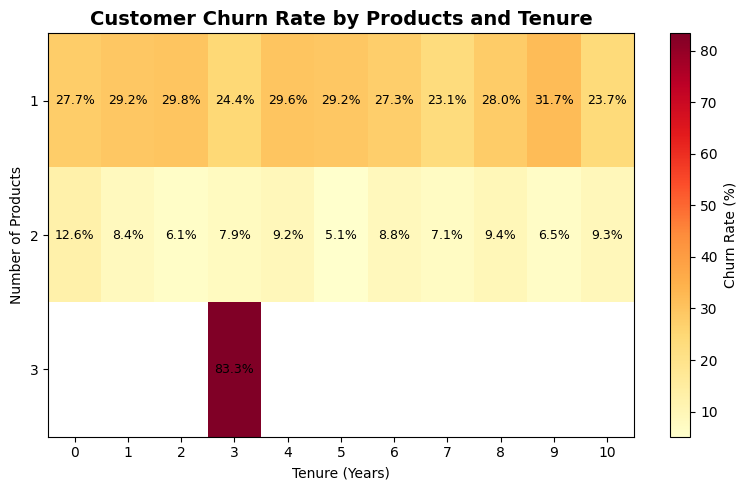

In [18]:


# Create pivot table
heatmap_data = df4.pivot_table(
    index="NumOfProducts",
    columns="Tenure",
    values="churn_rate",
    aggfunc="mean"   # Average churn rate for duplicates
)

# Plot heatmap
plt.figure(figsize=(8,5))
plt.imshow(heatmap_data, cmap="YlOrRd", aspect="auto")

# Color bar
plt.colorbar(label="Churn Rate (%)")

# Axis labels
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

# Add data labels
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if pd.notna(value):
            plt.text(j, i, f"{value:.1f}%", ha="center", va="center", fontsize=9)

plt.title("Customer Churn Rate by Products and Tenure", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

**6.Divide customers into Credit Score bands (Poor, Fair, Good, Excellent). Which segment contributes the most balance, and which has the highest churn?**

In [19]:
df5=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query6.csv")
df5

,number_of_customers,credit_score_band,total_balance,churn_rate
0,19,Poor,92257.35,100.00
1,3818,Good,76913.48,19.72
2,3116,Excellent,76819.15,19.87
3,3047,Fair,75510.95,21.20


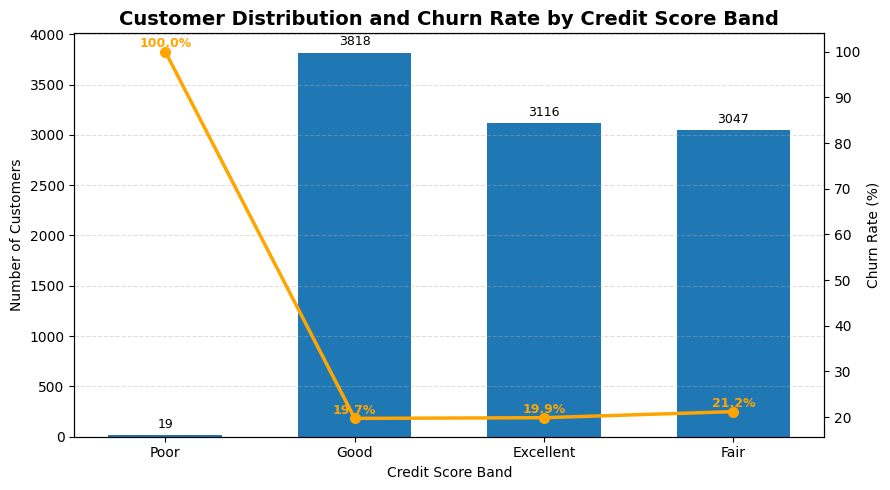

In [20]:


# Create figure
fig, ax1 = plt.subplots(figsize=(9,5))

# Bar Chart - Number of Customers
bars = ax1.bar(df5["credit_score_band"], df5["number_of_customers"], width=0.6)

# Data labels for bars
ax1.bar_label(bars, padding=3, fontsize=9)

ax1.set_xlabel("Credit Score Band")
ax1.set_ylabel("Number of Customers")
ax1.set_title("Customer Distribution and Churn Rate by Credit Score Band",
              fontsize=14, fontweight="bold")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Secondary Axis - Churn Rate
ax2 = ax1.twinx()

ax2.plot(
    df5["credit_score_band"],
    df5["churn_rate"],
    color="orange",
    marker="o",
    linewidth=2.5,
    markersize=7
)

ax2.set_ylabel("Churn Rate (%)")

# Data labels for line
for x, y in zip(df5["credit_score_band"], df5["churn_rate"]):
    ax2.text(
        x,
        y + 1,
        f"{y:.1f}%",
        color="orange",
        fontsize=9,
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**7.Find the top 5 customers by balance within each country.**

In [21]:
df6=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query7.csv")
df6

,Geography,BRank,CustomerId,Surname,Balance
0,France,1,15715622,To Rot,238387.56
1,France,2,15769818,Moore,212778.20
2,France,3,15780212,Mao,212692.97
3,France,4,15690589,Udinesi,212314.03
4,France,5,15671256,Macartney,211774.31
5,Germany,1,15599131,Dilke,214346.96
6,Germany,2,15620268,Thomson,212696.32
7,Germany,3,15795298,Olisaemeka,206868.78
8,Germany,4,15745433,Conti,205770.78
9,Germany,5,15663888,Connor,204017.40


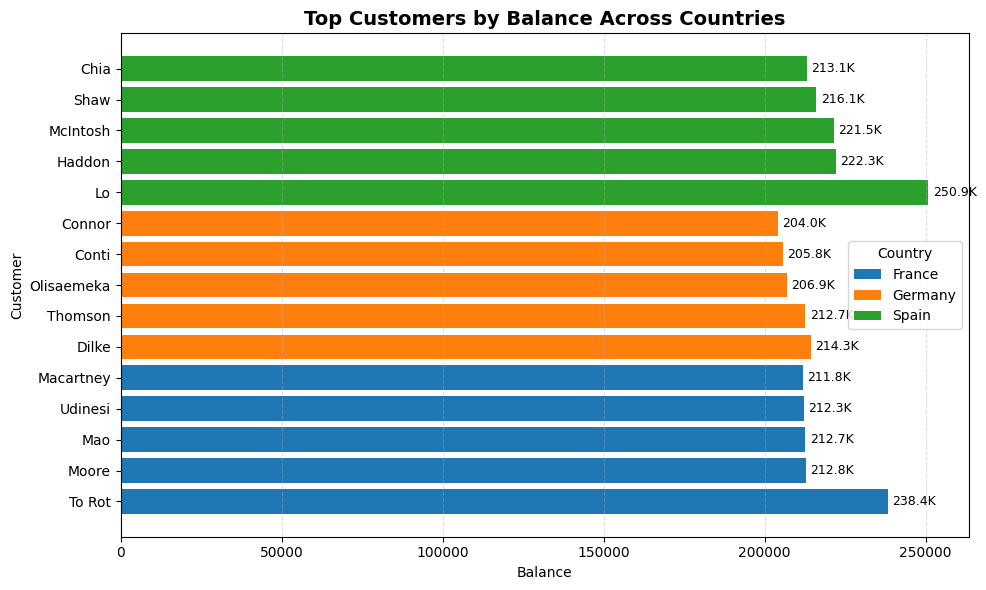

In [22]:


# Sort by Country and Rank
df6 = df6.sort_values(["Geography", "BRank"])

# Create figure
plt.figure(figsize=(10,6))

# Plot each country separately
for country in df6["Geography"].unique():
    country_data = df6[df6["Geography"] == country]

    bars = plt.barh(
        country_data["Surname"],
        country_data["Balance"],
        label=country
    )

    # Data labels
    plt.bar_label(
        bars,
        labels=[f"{x/1000:.1f}K" for x in country_data["Balance"]],
        padding=3,
        fontsize=9
    )

# Formatting
plt.title("Top Customers by Balance Across Countries", fontsize=14, fontweight="bold")
plt.xlabel("Balance")
plt.ylabel("Customer")
plt.legend(title="Country")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**8.Build a Customer Risk Score using multiple conditions (credit score, activity, tenure, products, balance) and classify customers as Low, Medium, High Risk.**

In [23]:
df7=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query8.csv")
df7

,CustomerId,Surname,risk_score,Risk_Category
0,15634602,Hargrave,7,Low Risk
1,15647311,Hill,5,Medium Risk
2,15619304,Onio,3,Medium Risk
3,15701354,Boni,6,Low Risk
4,15737888,Mitchell,4,Medium Risk
...,...,...,...,...
9995,15606229,Obijiaku,4,Medium Risk
9996,15569892,Johnstone,3,Medium Risk
9997,15584532,Liu,4,Medium Risk
9998,15682355,Sabbatini,2,Medium Risk


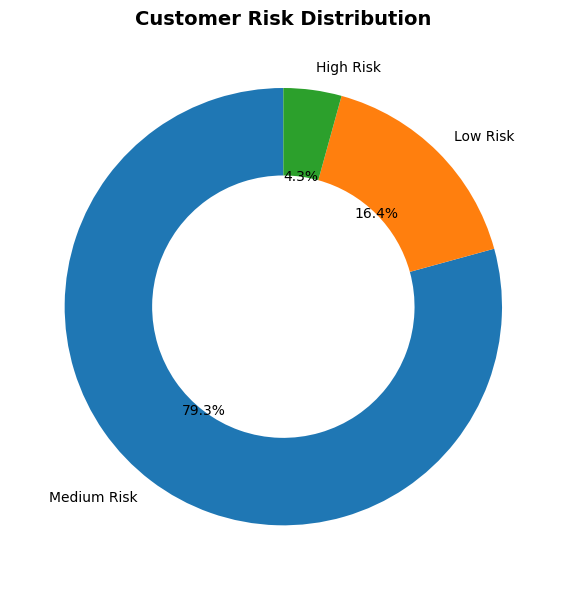

In [24]:


# Count customers in each risk category
risk_counts = df7["Risk_Category"].value_counts()

# Create figure
plt.figure(figsize=(6,6))

# Donut chart
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Customer Risk Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**9.Which age groups generate the highest average balance but also experience high churn?**

In [25]:
df8=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query9.csv")
df8

,age_group,avg_balance,churn_rate
0,50-64,82643.44,53.10
1,30-49,76352.77,18.37
2,18-29,73698.72,7.56
3,65-79,73196.18,15.73
4,80+,44872.74,6.67


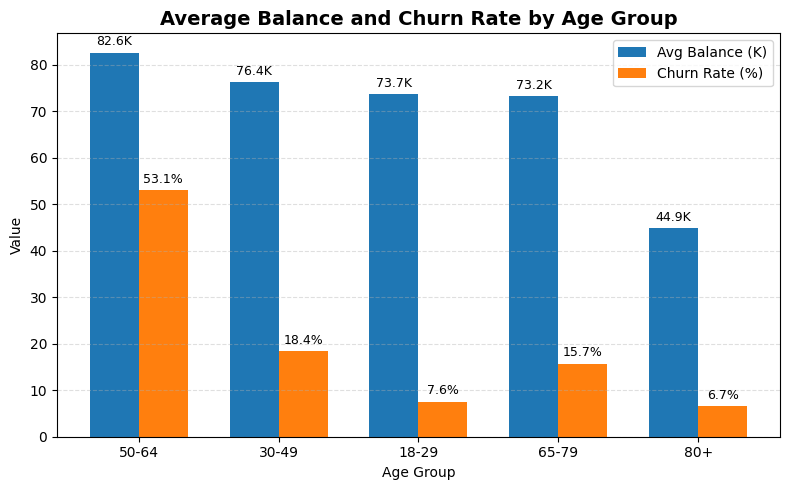

In [26]:


# Convert balance to thousands
df8["avg_balance_k"] = df8["avg_balance"] / 1000

# X positions
x = np.arange(len(df8))
width = 0.35

# Create figure
plt.figure(figsize=(8,5))

# Bars
bars1 = plt.bar(x - width/2, df8["avg_balance_k"], width, label="Avg Balance (K)")
bars2 = plt.bar(x + width/2, df8["churn_rate"], width, label="Churn Rate (%)")

# Data labels
plt.bar_label(bars1,
              labels=[f"{v:.1f}K" for v in df8["avg_balance_k"]],
              padding=3,
              fontsize=9)

plt.bar_label(bars2,
              labels=[f"{v:.1f}%" for v in df8["churn_rate"]],
              padding=3,
              fontsize=9)

# Formatting
plt.xticks(x, df8["age_group"])
plt.xlabel("Age Group")
plt.ylabel("Value")
plt.title("Average Balance and Churn Rate by Age Group",
          fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

**10.Identify customers whose balance is above their country's average balance.**

In [27]:
df9=pd.read_csv(r"D:\Resume_projects\SQL_Project\data\query10.csv")
df9

,CustomerId,Surname,Geography,Balance,Country_Avg_Balance
0,15711457,Herz,France,124540.28,62092.64
1,15795290,Nikitina,France,133616.39,62092.64
2,15794159,Highett,France,124281.84,62092.64
3,15815316,Kennedy,France,76817.00,62092.64
4,15722599,Nelson,France,183613.66,62092.64
...,...,...,...,...,...
4995,15744913,Chizoba,Spain,109632.85,61818.15
4996,15683276,Sargood,Spain,140363.95,61818.15
4997,15711571,Y?,Spain,120233.83,61818.15
4998,15569917,Obijiaku,Spain,87609.68,61818.15


<Figure size 800x500 with 0 Axes>

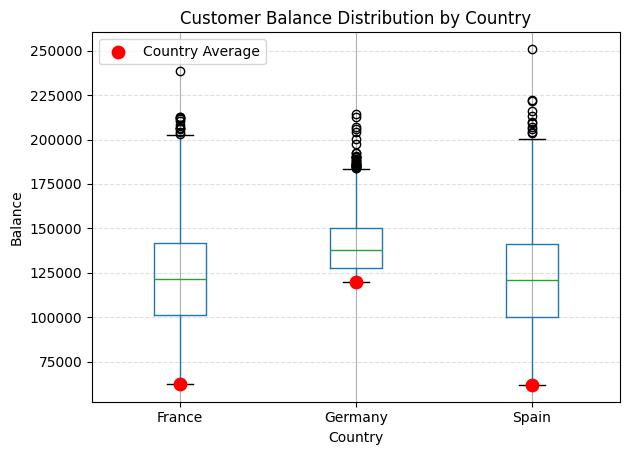

In [29]:


plt.figure(figsize=(8,5))

# Box plot
df9.boxplot(column="Balance", by="Geography")

# Country average as red dots
avg = df9.groupby("Geography")["Country_Avg_Balance"].first()

plt.scatter(
    range(1, len(avg)+1),
    avg.values,
    color="red",
    s=80,
    label="Country Average",
    zorder=3
)

plt.title("Customer Balance Distribution by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Balance")
plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()